# Task 3.1: Embeddings contextuales con BERT multilingüe

## Imports y reproducibilidad

In [1]:
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from transformers import AutoModel, AutoTokenizer

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## Oraciones y palabras objetivo

In [2]:
# (oración, palabra objetivo, significado)
SENTENCES = [
    ("El banco central anunció una subida de tasas de interés.", "banco", "banco · finanzas"),
    ("Me senté en el banco del parque a leer el periódico.", "banco", "banco · asiento"),
    ("El banco de peces se movió velozmente ante el tiburón.", "banco", "banco · peces"),
    ("El equipo levantó la copa del torneo ante miles de aficionados.", "copa", "copa · trofeo"),
    ("Sirvió una copa de vino tinto para acompañar la cena.", "copa", "copa · vino"),
    ("El velero desplegó su vela para aprovechar el viento.", "vela", "vela · barco"),
    ("Encendió una vela para iluminar el cuarto durante el apagón.", "vela", "vela · luz"),
]

## Carga del modelo

In [3]:
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert.eval()
print("capas:", bert.config.num_hidden_layers, "| d_model:", bert.config.hidden_size)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


capas: 12 | d_model: 768


## Extracción del embedding de la palabra objetivo

In [ ]:
@torch.no_grad()
def word_embedding(sentence, word):
    """Embedding de la última capa para `word` dentro de `sentence`.

    BERT procesa la oración completa con atención bidireccional sin máscara causal, 
    así que el vector h_i de cada token depende de todos los tokens de la oración. Por eso la 
    misma palabra recibe vectores distintos en contextos distintos.

    WordPiece puede partir la palabra en varios subtokens (p. ej. "vel", "##a"). En ese caso se promedian sus vectores. 
    Nunca se usa el token [CLS].
    """
    start = sentence.index(word)
    end = start + len(word)
    enc = tokenizer(sentence, return_tensors="pt", return_offsets_mapping=True)
    offsets = enc.pop("offset_mapping")[0]
    hidden = bert(**enc.to(device)).last_hidden_state[0].cpu()

    # subtokens cuyo rango de caracteres cae dentro de la palabra ([CLS]/[SEP] tienen offset (0, 0))
    idx = [i for i, (s, e) in enumerate(offsets.tolist()) if e > s and s >= start and e <= end]
    pieces = tokenizer.convert_ids_to_tokens(enc["input_ids"][0][idx].tolist())
    return hidden[idx].mean(dim=0), pieces


embeddings = []
for sentence, word, meaning in SENTENCES:
    vec, pieces = word_embedding(sentence, word)
    embeddings.append(vec)
    print(f"{meaning:18} subtokens {pieces}  dim {tuple(vec.shape)}")

E = torch.stack(embeddings)
assert E.shape == (len(SENTENCES), 768)

banco · finanzas   subtokens ['banco']  dim (768,)
banco · asiento    subtokens ['banco']  dim (768,)


banco · peces      subtokens ['banco']  dim (768,)
copa · trofeo      subtokens ['copa']  dim (768,)


copa · vino        subtokens ['copa']  dim (768,)
vela · barco       subtokens ['vela']  dim (768,)


vela · luz         subtokens ['vela']  dim (768,)


# Task 3.2: Comparación con embeddings estáticos

## a. Similitud coseno entre contextos (BERT)

In [ ]:
def cosine(u, v):
    u, v = np.asarray(u, dtype=np.float64), np.asarray(v, dtype=np.float64)
    return float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))

PAIRS = [
    (i, j)
    for i, j in itertools.combinations(range(len(SENTENCES)), 2)
    if SENTENCES[i][1] == SENTENCES[j][1]
]

bert_table = pd.DataFrame(
    [
        {
            "palabra": SENTENCES[i][1],
            "contexto 1": SENTENCES[i][2].split(" · ")[1],
            "contexto 2": SENTENCES[j][2].split(" · ")[1],
            "sim BERT": cosine(E[i], E[j]),
        }
        for i, j in PAIRS
    ]
)
bert_table.round(4)

,palabra,contexto 1,contexto 2,sim BERT
0,banco,finanzas,asiento,0.5753
1,banco,finanzas,peces,0.6603
2,banco,asiento,peces,0.6496
3,copa,trofeo,vino,0.5667
4,vela,barco,luz,0.7999


Como referencia, la matriz completa de similitudes entre las 7 instancias (incluye pares de palabras distintas):

In [6]:
labels = [m for _, _, m in SENTENCES]
sim_matrix = pd.DataFrame(
    [[cosine(E[i], E[j]) for j in range(len(E))] for i in range(len(E))],
    index=labels,
    columns=labels,
)
sim_matrix.round(3)

,banco · finanzas,banco · asiento,banco · peces,copa · trofeo,copa · vino,vela · barco,vela · luz
banco · finanzas,1.000,0.575,0.660,0.323,0.330,0.360,0.354
banco · asiento,0.575,1.000,0.650,0.351,0.383,0.323,0.343
banco · peces,0.660,0.650,1.000,0.353,0.443,0.443,0.440
copa · trofeo,0.323,0.351,0.353,1.000,0.567,0.464,0.426
copa · vino,0.330,0.383,0.443,0.567,1.000,0.430,0.494
vela · barco,0.360,0.323,0.443,0.464,0.430,1.000,0.800
vela · luz,0.354,0.343,0.440,0.426,0.494,0.800,1.000


## b. Word2Vec preentrenado (gensim)

In [ ]:
import gensim.downloader as api

# Word2Vec skip-gram entrenado sobre Google News (300 dimensiones).
w2v = api.load("word2vec-google-news-300")
print("vocabulario:", len(w2v.key_to_index), "| dim:", w2v.vector_size)

vocabulario: 3000000 | dim: 300


In [ ]:
def static_vector(word):
    for form in (word, word.capitalize()):
        if form in w2v.key_to_index:
            return w2v[form], form
    raise KeyError(f"{word!r} no está en el vocabulario de Word2Vec")


# El vector se obtiene solo a partir de la palabra.
static = {}
for word in sorted({w for _, w, _ in SENTENCES}):
    static[word] = static_vector(word)
    vec, form = static[word]
    neighbors = ", ".join(n for n, _ in w2v.most_similar(form, topn=8))
    print(f"{word:6} (como {form!r})  vecinos: {neighbors}")

banco  (como 'banco')  vecinos: arriba, forza, deus, apenas, próxima, mesi, nostra, nuova


copa   (como 'copa')  vecinos: boca, diez, você, ojos, solamente, el_es, fresca, comida


vela   (como 'vela')  vecinos: roberto, feliz, eto, tú, clase, suerte, quién, eso


In [9]:
w2v_sims = []
for i, j in PAIRS:
    vi = static[SENTENCES[i][1]][0]  # mismo vector sin importar la oración
    vj = static[SENTENCES[j][1]][0]
    w2v_sims.append(cosine(vi, vj))

comparison = bert_table.assign(**{"sim Word2Vec": w2v_sims})
comparison["diferencia"] = comparison["sim Word2Vec"] - comparison["sim BERT"]
comparison.round(4)

,palabra,contexto 1,contexto 2,sim BERT,sim Word2Vec,diferencia
0,banco,finanzas,asiento,0.5753,1.0,0.4247
1,banco,finanzas,peces,0.6603,1.0,0.3397
2,banco,asiento,peces,0.6496,1.0,0.3504
3,copa,trofeo,vino,0.5667,1.0,0.4333
4,vela,barco,luz,0.7999,1.0,0.2001


## c. PCA de los embeddings de BERT

varianza explicada: [0.35  0.235] | total: 0.586


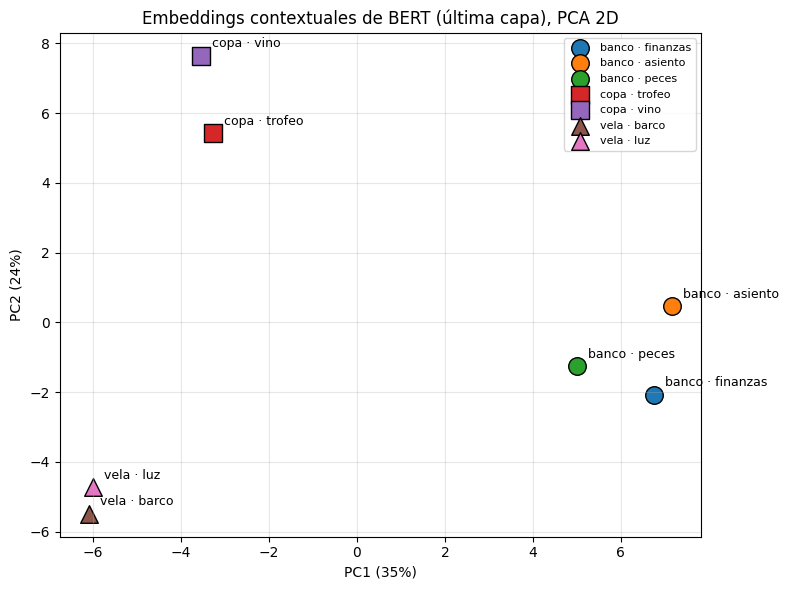

In [10]:
# PCA: proyecta los vectores centrados sobre las 2 direcciones de mayor varianza
pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(E.numpy())
print("varianza explicada:", pca.explained_variance_ratio_.round(3), "| total:", pca.explained_variance_ratio_.sum().round(3))

MARKERS = {"banco": "o", "copa": "s", "vela": "^"}
colors = plt.cm.tab10(np.arange(len(SENTENCES)))

plt.figure(figsize=(8, 6))
for k, (_, word, meaning) in enumerate(SENTENCES):
    plt.scatter(Z[k, 0], Z[k, 1], s=160, marker=MARKERS[word], color=colors[k], label=meaning, edgecolor="black")
    plt.annotate(meaning, Z[k], textcoords="offset points", xytext=(8, 6), fontsize=9)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
plt.title("Embeddings contextuales de BERT (última capa), PCA 2D")
plt.legend(loc="best", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_task3.png", dpi=110)
plt.show()

In [ ]:
for i, j in PAIRS:
    print(f"{SENTENCES[i][2]:18} - {SENTENCES[j][2]:18} distancia 2D {np.linalg.norm(Z[i] - Z[j]):6.2f}")

banco · finanzas   - banco · asiento    distancia 2D   2.58
banco · finanzas   - banco · peces      distancia 2D   1.94
banco · asiento    - banco · peces      distancia 2D   2.77
copa · trofeo      - copa · vino        distancia 2D   2.24
vela · barco       - vela · luz         distancia 2D   0.77


## Respuestas

**a. Similitud coseno con BERT**

Ninguna similitud entre usos de la misma palabra llega a 1. "Banco" queda entre 0.58 (finanzas contra asiento) y 0.66 (finanzas contra peces). "Copa" da 0.57 entre trofeo y vino, y "vela" da 0.80 entre barco y luz. Es decir, BERT le da a la misma palabra un vector distinto en cada oración.

Esto pasa porque BERT usa atención bidireccional, sin máscara. El vector de "banco" en la última capa sale de softmax(QK^T / sqrt(d_k)) V aplicado sobre toda la oración, así que mezcla información de "central", "tasas de interés", "parque" o "peces". Para lo que sigue igual, la palabra de entrada es la misma, el vector inicial de "banco" es idéntico en las tres oraciones y solo cambia lo que el contexto le agrega.

En la matriz completa se ve el otro lado. Entre palabras distintas, por ejemplo "banco" contra "copa", la similitud baja a entre 0.32 y 0.49. Así que dos usos de "banco" se parecen más entre sí que a cualquier otra palabra, pero no son el mismo vector. El par menos separado es "vela" (0.80). Una posible explicación es que las dos oraciones tienen casi la misma forma, verbo + "su/una vela" + "para" + infinitivo, y BERT también codifica la estructura de la oración, no solo el significado.

**b. Comparación con Word2Vec**

Con Word2Vec la similitud es 1.0 en los 5 pares. No es un resultado del entrenamiento sino de cómo funciona. Word2Vec es una tabla que asigna un solo vector a cada palabra, y la oración nunca entra en el cálculo. Si u = v, entonces sim(u, v) = u^T u / (||u|| ||u||) = 1. La diferencia con BERT va de 0.20 (vela) a 0.43 (copa).

Además, el modelo de gensim está entrenado con noticias en inglés. Sí tiene "banco", "copa" y "vela" en el vocabulario, pero aparecen pocas veces y en fragmentos en otros idiomas. Por eso sus vecinos más cercanos no tienen relación. "arriba, forza, deus" para banco, "boca, diez, você" para copa y "roberto, feliz, eto" para vela. Con un Word2Vec entrenado en español los vecinos serían mejores, pero la similitud entre contextos seguiría siendo exactamente 1.0.

**c. PCA de los embeddings de BERT**

Las dos primeras componentes explican el 59 por ciento de la varianza (35 y 24 por ciento). Hay que tomarlo con cuidado, porque son solo 7 puntos en 768 dimensiones.

La separación más fuerte es por palabra. Se forman tres grupos: 
- los "banco" a la derecha
- las "copa" arriba a la izquierda 
- las "vela" abajo a la izquierda. 

PC1 separa "banco" de las otras dos y PC2 separa "copa" de "vela".

Dentro de cada grupo los significados sí se separan, pero menos. En el plano, los tres "banco" quedan a distancias de 1.9 a 2.8 entre sí y las dos "copa" a 2.24. Las dos "vela" quedan casi juntas (0.77), lo cual coincide con su similitud alta de 0.80. Los embeddings contextuales capturan el significado según el contexto, algo que Word2Vec no puede hacer porque siempre devuelve el mismo punto. Pero el contexto no borra la identidad de la palabra. BERT mueve cada instancia dentro de una región propia de esa palabra, no a una región completamente distinta.